In [1]:
# ── Block 1: Imports & Load ─────────────────────────────
import shap
import joblib
import numpy as np
import matplotlib.pyplot as plt

best_rf     = joblib.load('best_rf_model.pkl')
X_train, x_test, y_train, y_test = joblib.load('train_test_splits.pkl')
feature_cols = joblib.load('feature_columns.pkl')

print("Model and data loaded.")
print("X_test shape:", x_test.shape)

Model and data loaded.
X_test shape: (175, 34)


In [2]:
# ── Block 2: Build SHAP Explainer ──────────────────────
explainer   = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(x_test)

print("shap_values shape:", shap_values.shape)   # expect (175, 34, 2)
print("expected_value:", explainer.expected_value)

shap_values shape: (175, 34, 2)
expected_value: [0.54129286 0.45870714]


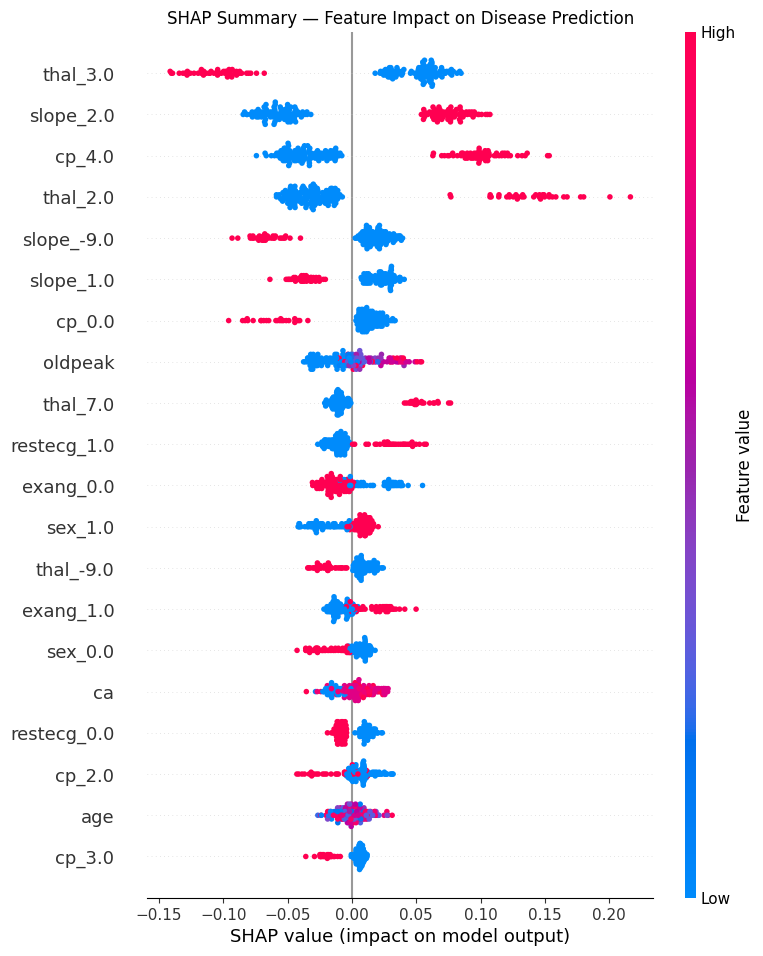

Summary plot saved.


In [3]:
# ── Block 3: Global Summary Plot ───────────────────────
shap.summary_plot(
    shap_values[:, :, 1],      # class 1 = disease
    x_test,
    feature_names=feature_cols,
    show=False
)
plt.title("SHAP Summary — Feature Impact on Disease Prediction")
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Summary plot saved.")

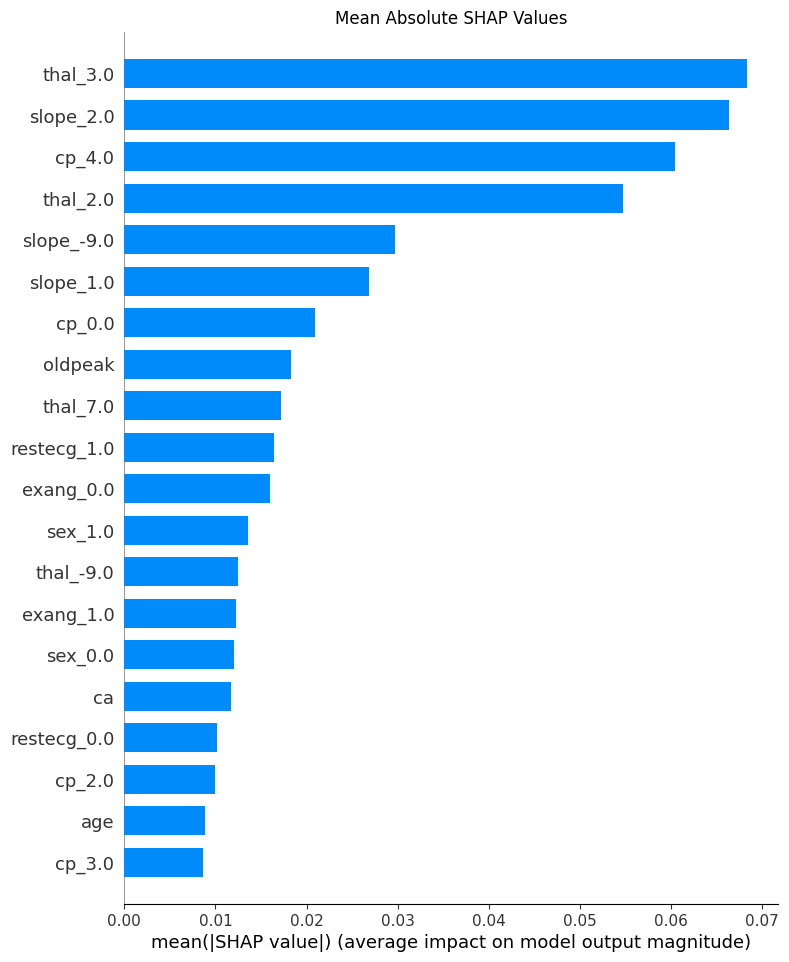

Bar plot saved.


In [4]:
# ── Block 4: Bar Plot (mean absolute SHAP) ─────────────
shap.summary_plot(
    shap_values[:, :, 1],
    x_test,
    feature_names=feature_cols,
    plot_type='bar',
    show=False
)
plt.title("Mean Absolute SHAP Values")
plt.savefig('shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("Bar plot saved.")

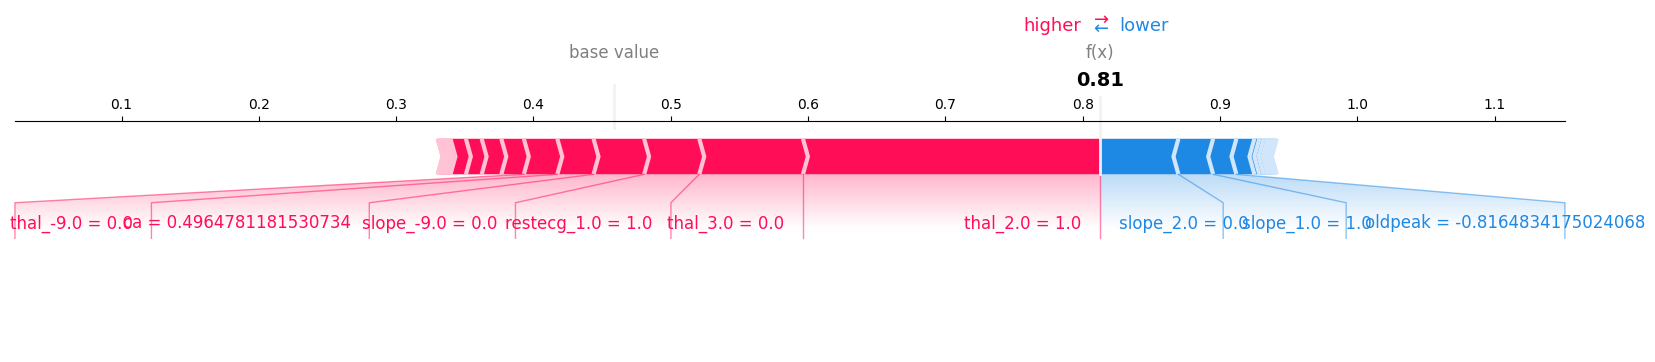

Force plot saved.


In [5]:
# ── Block 5: Force Plot (single prediction) ────────────
sv = shap_values[0, :, 1]        # first test sample, disease class
ev = explainer.expected_value[1]

shap.force_plot(
    ev,
    sv,
    x_test.iloc[0],
    feature_names=feature_cols,
    matplotlib=True,
    show=False
)
plt.savefig('shap_force_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Force plot saved.")

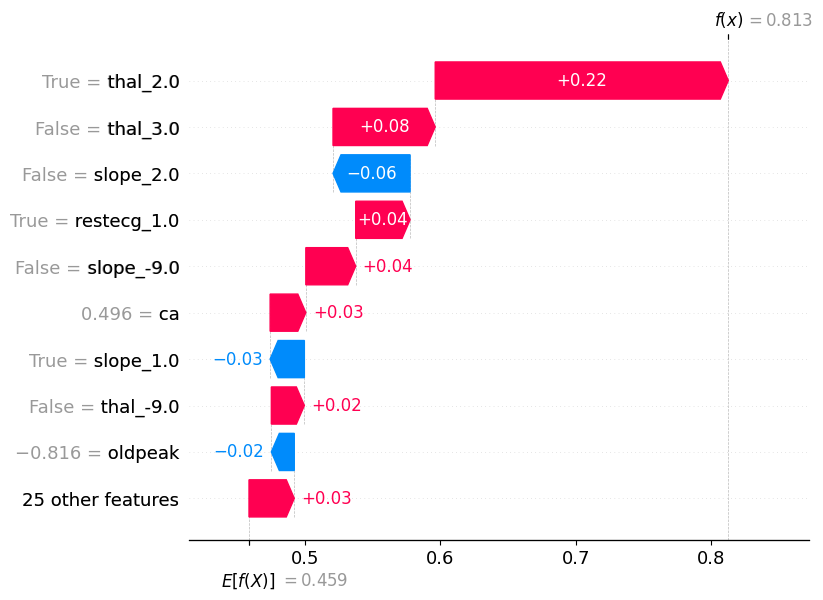

Waterfall plot saved.


In [6]:
# ── Block 6: Waterfall Plot (cleaner single explanation)
explanation = shap.Explanation(
    values      = shap_values[0, :, 1],
    base_values = explainer.expected_value[1],
    data        = x_test.iloc[0].values,
    feature_names = feature_cols
)

shap.plots.waterfall(explanation, show=False)
plt.savefig('shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()
print("Waterfall plot saved.")

In [7]:
# ── Block 7: Save SHAP values for use in Flask API later
joblib.dump(explainer, 'shap_explainer.pkl')
print("SHAP explainer saved — ready for Phase 6 (Flask API).")
print("\nPhase 4 complete. Files saved:")
print("  shap_summary.png")
print("  shap_bar.png")
print("  shap_force_plot.png")
print("  shap_waterfall.png")
print("  shap_explainer.pkl")

SHAP explainer saved — ready for Phase 6 (Flask API).

Phase 4 complete. Files saved:
  shap_summary.png
  shap_bar.png
  shap_force_plot.png
  shap_waterfall.png
  shap_explainer.pkl
